In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_file='products_asos.csv' #assign variable to input file
df = pd.read_csv(input_file, on_bad_lines='skip') #create DataFrame from the input file skipping bad lines

df['price'] = pd.to_numeric(df['price'], errors='coerce') #force price column to be all numeric, bring non numeric values to NaN
df = df.dropna(subset=['price']) #remove row from table if there is a NaN in price column

print(f"Data Loaded: {len(df)} rows")

df.head()

Data Loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [4]:
#audit the data to see where they are loosing money as an outsider of the company
#find the brand name in the description column
df['description'] = df['description'].astype(str) #convert description to string

#in description, there is a pattern to differentiate the bran after the word "by", we will use that to slice the string
def GetBrand(text):
    if 'by' in text: #when 'by' is found, then do:
        try:
            return text.split('by ')[1].split(' ')[0] #split text when the word "by " is found, and take the second part of the sliced string with the [1], then split again on a space and take the first part, which is the brand name
        except:
            return "Unknown"
    return "Unknown"

df['brand_raw'] = df['description'].apply(GetBrand) #apply function to description, obtaining the raw data of brands


In [5]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [6]:
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'MissSelfridge',
    'TopshopWelcome': 'Topshop'
} #create dictionary to map keywords to unuseful data to filter it out

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw']) #create new df based on raw data filtering out the unuseful data

brand_counts = df['Brand'].value_counts() #find the count of brands
valid_brands = brand_counts[brand_counts > 5].index #only make brands that appear over 5 times as valid brands
df_clean = df[df['Brand'].isin(valid_brands)].copy() #clean the df with only the valid brands

print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS             4844
Topshop          1017
New Look          511
River Island      467
MissSelfridge     429
Name: count, dtype: int64


In [10]:
#function to analyze stockouts
def CalculatePhantomRevenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0

    #split "UK 6, UK 8 - Out of stock" into list
    sizes = size_str.split(',')
    total_sizes = len(sizes)

    #count how many items are out of stock
    out_of_stock_count = size_str.count('Out of stock')

    #calculate rate (0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

    return out_of_stock_count, rate #return out of stock count and rate of phantom revenue

metrics = df_clean['size'].apply(lambda x: CalculatePhantomRevenue(x)) #apply function to df_clean and save to metrics the two values
#print(metrics)

df_clean['Stockout_Count'] = [x[0] for x in metrics] #add column related to the stockout counts
df_clean['Stockout_Rate'] = [x[1] for x in metrics] #add column related to the stockout rate

df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stockout_Count'] #find the lost revenue multiplying the price by the stouckout count

cols = ['Brand','name', 'price', 'Stockout_Count', 'Lost_Revenue'] #columns we want to see in report
print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols]) #print report ordered by lost revenue with columns in las variable

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


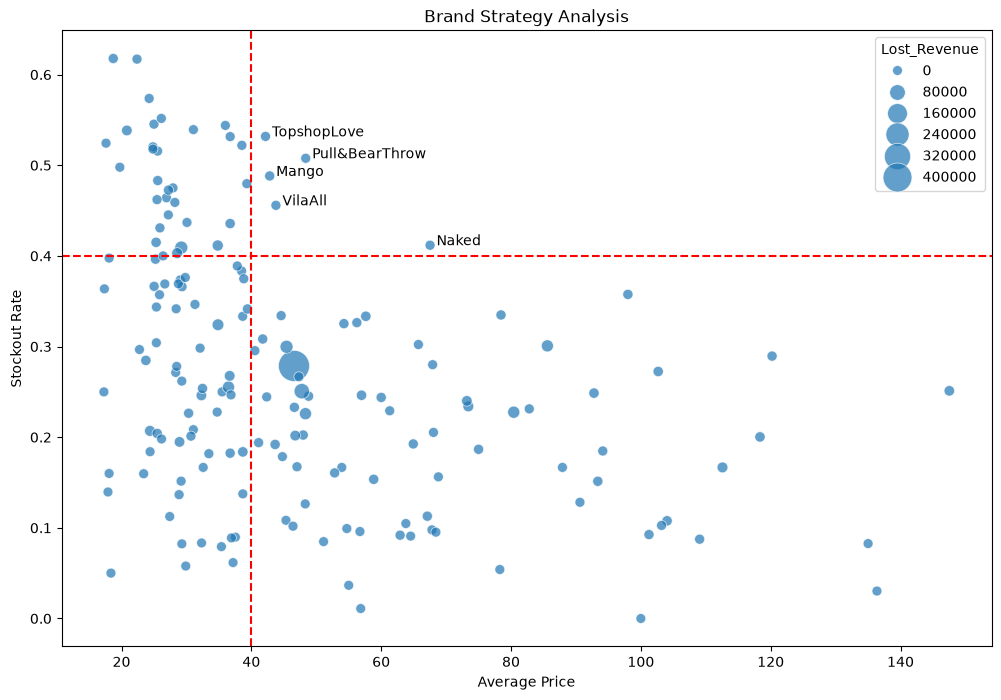

In [13]:
#aggregate data to get strategic ideas on some brands
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate':'mean',
    'Lost_Revenue':'sum',
    'name':'count'
}).reset_index() #aggregate new columns to df

brand_strategy = brand_strategy[brand_strategy['name'] > 10] #find common brands

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    size='Lost_Revenue',
    sizes=(50, 500),
    alpha=0.7,
) #organize the plot figures based on interest

winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)
] #find the brands that meet these criteria of high price and high stockout rate

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['Brand']
    ) #write the names of the brands that meet the previous criteria

plt.title('Brand Strategy Analysis') #plot title
plt.xlabel('Average Price') #x axis label
plt.ylabel('Stockout Rate') #y axis label
plt.axvline(x=40, color='red', linestyle='--') #x axis vertical threshold line
plt.axhline(y=0.4, color='red', linestyle='--') #y axis horizontal threshold line
plt.show() #print the plot